In [2]:
import pandas as pd
import json
import os

class CEA_Evaluator:
    def __init__(self, answer_file_path, round=1):
        self.answer_file_path = answer_file_path
        self.round = round

    def _evaluate(self, client_payload, _context={}):

        submission_file_path = client_payload["submission_file_path"]
        gt_cell_ent = dict()
        gt = pd.read_csv(self.answer_file_path, delimiter=',', names=['tab_id', 'row_id', 'col_id', 'entity'],dtype={'tab_id': str, 'row_id': str, 'col_id': str, 'entity': str}, keep_default_na=False)
        for _, row in gt.iterrows():
            cell = '%s %s %s' % (row['tab_id'], row['row_id'], row['col_id'])
            gt_cell_ent[cell] = row['entity']

        correct_cells, annotated_cells = set(), set()
        sub = pd.read_csv(submission_file_path, delimiter=',', names=['tab_id', 'row_id', 'col_id', 'entity'],dtype={'tab_id': str, 'row_id': str, 'col_id': str, 'entity': str}, keep_default_na=False)
        for _, row in sub.iterrows():
            cell = '%s %s %s' % (row['tab_id'], row['row_id'], row['col_id'])
            if cell in gt_cell_ent:
                if cell in annotated_cells:
                    print(cell)
                    raise Exception("Duplicate cells in the submission file")
                else:
                    annotated_cells.add(cell)

                annotation = row['entity']
                if not annotation.startswith('http://www.wikidata.org/entity/'):
                    annotation = 'http://www.wikidata.org/entity/' + annotation

                if annotation.lower() in gt_cell_ent[cell].lower().split():
                    correct_cells.add(cell)
                else:
                    #print('%s,%s' % (cell.replace(' ', ','), gt_cell_ent[cell]))
                    continue

        precision = len(correct_cells) / len(annotated_cells) if len(annotated_cells) > 0 else 0.0
        recall = len(correct_cells) / len(gt_cell_ent.keys())
        f1 = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
        main_score = f1
        secondary_score = precision
        print('F1: %.3f, Precision: %.3f, Recall: %.3f' % (f1, precision, recall))
        _result_object = {
            "score": main_score,
            "score_secondary": secondary_score
        }
        return _result_object

class CTA_Evaluator:
  def __init__(self, answer_file_path, gt_ancestor, gt_descendent, round=1):
    self.answer_file_path = answer_file_path
    self.gt_ancestor = gt_ancestor
    self.gt_descendent = gt_descendent
    self.round = round

  def _evaluate(self, client_payload, _context={}):
    submission_file_path = client_payload["submission_file_path"]

    cols, col_type = set(), dict()
    gt = pd.read_csv(self.answer_file_path, delimiter=',', names=['tab_id', 'col_id', 'type'], dtype={'tab_id': str, 'col_id': str, 'type': str}, keep_default_na=False)
    for _, row in gt.iterrows():
        col = '%s %s' % (row['tab_id'], row['col_id'])
        gt_type = row['type']
        col_type[col] = gt_type
        cols.add(col)

    annotated_cols = set()
    total_score = 0
    sub = pd.read_csv(submission_file_path, delimiter=',', names=['tab_id', 'col_id', 'annotation'],dtype={'tab_id': str, 'col_id': str, 'annotation': str}, keep_default_na=False)
    for _, row in sub.iterrows():
        col = '%s %s' % (row['tab_id'], row['col_id'])
        if col in annotated_cols:
            # continue
            print(col)
            raise Exception("Duplicate columns in the submission file")
        else:
            annotated_cols.add(col)
        annotation = row['annotation']
        if not annotation.startswith('http://www.wikidata.org/entity/'):
            annotation = 'http://www.wikidata.org/entity/' + annotation

        if col in cols:
            max_score = 0
            for gt_type in col_type[col].split():
                ancestor = self.gt_ancestor[gt_type]
                ancestor_keys = [k.lower() for k in ancestor]
                descendent = self.gt_descendent[gt_type]
                descendent_keys = [k.lower() for k in descendent]
                if annotation.lower() == gt_type.lower():
                    score = 1.0
                elif annotation.lower() in ancestor_keys:
                    depth = int(ancestor[annotation])
                    if depth <= 5:
                        score = pow(0.8, depth)
                    else:
                        score = 0
                elif annotation.lower() in descendent_keys:
                    depth = int(descendent[annotation])
                    if depth <= 3:
                        score = pow(0.7, depth)
                    else:
                        score = 0
                else:
                    score = 0
                if score > max_score:
                    max_score = score
            if max_score < 0.7:
                s_tmp = col.replace(' ', ',')
                #print('%s,%s' % (s_tmp, col_type[col]))
            total_score += max_score

    precision = total_score / len(annotated_cols) if len(annotated_cols) > 0 else 0
    recall = total_score / len(cols)
    f1 = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0

    main_score = f1
    secondary_score = precision

    print('F1: %.3f, Precision: %.3f, Recall: %.3f' % (f1, precision, recall))

    _result_object = {
        "score": main_score,
        "score_secondary": secondary_score
    }
    return _result_object
  
class CPA_Evaluator:
  def __init__(self, answer_file_path, round=1):
    self.answer_file_path = answer_file_path
    self.round = round

  def _evaluate(self, client_payload, _context={}):
    submission_file_path = client_payload["submission_file_path"]

    gt_cols_pro = dict()
    gt = pd.read_csv(self.answer_file_path, delimiter=',', names=['tab_id', 'sub_col_id', 'obj_col_id', 'property'],dtype={'tab_id': str, 'sub_col_id': str, 'obj_col_id': str, 'property': str}, keep_default_na=False)
    for _, row in gt.iterrows():
        cols = '%s %s %s' % (row['tab_id'], row['sub_col_id'], row['obj_col_id'])
        gt_cols_pro[cols] = row['property']

    annotated_cols, correct_cols = set(), set()
    sub = pd.read_csv(submission_file_path, delimiter=',', names=['tab_id', 'sub_col_id', 'obj_col_id', 'property'], dtype={'tab_id': str, 'sub_col_id': str, 'obj_row_id': str, 'property': str}, keep_default_na=False)
    for _, row in sub.iterrows():
        cols = '%s %s %s' % (row['tab_id'], row['sub_col_id'], row['obj_col_id'])
        if cols in gt_cols_pro:
            if cols in annotated_cols:
                # continue
                #print(cols)
                raise Exception("Duplicate column pairs in the submission file")
            else:
                annotated_cols.add(cols)
            annotation = row['property']
            if not annotation.startswith('http://www.wikidata.org/prop/direct/'):
                annotation = 'http://www.wikidata.org/prop/direct/' + annotation
            if annotation.lower() == gt_cols_pro[cols].lower():
                correct_cols.add(cols)
            else:
                #print('%s,%s' % (cols.replace(' ', ','), gt_cols_pro[cols]))
                continue

    precision = float(len(correct_cols)) / len(annotated_cols) if len(annotated_cols) > 0 else 0.0
    recall = float(len(correct_cols)) / len(gt_cols_pro.keys())
    f1 = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
    main_score = f1
    secondary_score = precision
    print('F1: %.3f, Precision: %.3f, Recall: %.3f' % (f1, precision, recall))

    _result_object = { "score": main_score,"score_secondary": secondary_score}
    return _result_object

In [1]:
import glob
import os   
def create_submission_file_basic_candidate(candidate_dir, out_file):
    rows = []

    for path in sorted(glob.glob(os.path.join(candidate_dir, "*_candidates.csv"))):
        fname = os.path.basename(path)
        tab_id = fname.replace("_candidates.csv", "")

        df = pd.read_csv(path)
        if df.empty:
            continue
        df = df.sort_values("quality", kind="stable")
        picks = df.groupby(["row", "columns"], sort=True).first().reset_index()

        for _, r in picks.iterrows():
            rows.append({"tab_id": tab_id,"row_id": int(r["row"]) +1,"col_id": int(r["columns"]),"entity": f"{r['QID']}"})

    out = pd.DataFrame(rows, columns=["tab_id", "row_id", "col_id", "entity"])
    out.to_csv(out_file, index=False, header=False)

    print(f"Files processed: {len(set(out['tab_id']))}")
    print(f"Total annotations: {len(out)}")
    print(f"Written to: {out_file}")


def evaluate_candidate_cea(candidate_dir,ground_truth_file):
    PREFIX = "http://www.wikidata.org/entity/"

    cell_cands = {}
    for path in sorted(glob.glob(os.path.join(candidate_dir, "*_candidates.csv"))):
        tab_id = os.path.basename(path).replace("_candidates.csv", "")
        df = pd.read_csv(path, dtype=str, keep_default_na=False)
        if df.empty:
            continue
        for _, r in df.iterrows():
            cell = f"{tab_id} {int(r['row']) + 1} {r['columns']}"
            cell_cands.setdefault(cell, set()).add(r["QID"])

    gt = pd.read_csv(ground_truth_file, names=["tab_id", "row_id", "col_id", "entity"],dtype=str, keep_default_na=False)

    total = len(gt)
    in_cands = 0
    no_cands_for_cell = 0

    for _, row in gt.iterrows():
        cell = f"{row['tab_id']} {row['row_id']} {row['col_id']}"
        gt_qid = row["entity"].replace(PREFIX, "")
        cands = cell_cands.get(cell)
        if not cands:
            no_cands_for_cell += 1
            continue
        if gt_qid in cands:
            in_cands += 1
    recall = in_cands / total if total else 0.0
    print(f"Evaluating candidates in {candidate_dir} against GT in {ground_truth_file}")
    print(f"GT cells:{total}")
    print(f"Cells with candidates retrieved:  {total - no_cands_for_cell}")
    print(f"GT entity present in candidates:   {in_cands}")
    print(f"Recall Maximum possible:  {recall:.3f}")

def evaluate_candidate_cea_more_details(candidate_dir,ground_truth_file):
    PREFIX = "http://www.wikidata.org/entity/"
    QUALITY_NAMES = {"1": "direct", "2": "llm", "3": "fuzzy"}

    cell_cands = {}
    cell_qualities = {}
    rows_per_quality = {}
    empty_cells = 0    
    for path in sorted(glob.glob(os.path.join(candidate_dir, "*_candidates.csv"))):
        tab_id = os.path.basename(path).replace("_candidates.csv", "")
        df = pd.read_csv(path, dtype=str, keep_default_na=False)
        if df.empty:
            continue
        for _, r in df.iterrows():
            cell = f"{tab_id} {int(r['row']) + 1} {r['columns']}"
            if r["QID"] == "":
                empty_cells += 1
                cell_cands.setdefault(cell, {})
                cell_qualities.setdefault(cell, set())
                continue
            quality = r["quality"]
            rows_per_quality[quality] = rows_per_quality.get(quality, 0) + 1
            cell_cands.setdefault(cell, {})[r["QID"]] = quality
            cell_qualities.setdefault(cell, set()).add(quality)

    gt = pd.read_csv(ground_truth_file, names=["tab_id", "row_id", "col_id", "entity"],dtype=str, keep_default_na=False)

    total = len(gt)
    in_cands = 0
    no_cands_for_cell = 0
    less_than_one_cands = 0
    more_than_five_cands = 0
    check_quality_1 = 0
    check_quality_2 = 0
    check_quality_3 = 0

    for _, row in gt.iterrows():
        cell = f"{row['tab_id']} {row['row_id']} {row['col_id']}"
        gt_qid = row["entity"].replace(PREFIX, "")
        cands = cell_cands.get(cell)
        if not cands:
            no_cands_for_cell += 1
            continue
        if gt_qid in cands:
            in_cands += 1
            quality = cands[gt_qid]
            if quality == '1':
                check_quality_1 += 1
            elif quality == '2':
                check_quality_2 += 1
            elif quality == '3':
                check_quality_3 += 1
        else:
            if len(cands) <= 1:
                less_than_one_cands += 1
            if len(cands) > 5:
                more_than_five_cands += 1

    recall = in_cands / total if total else 0.0
    print(f"Evaluating candidates in {candidate_dir} against GT in {ground_truth_file}")
    print(f"GT cells:{total}")
    print(f"Cells with candidates retrieved:{total - no_cands_for_cell}")
    print(f"GT entity present in candidates:{in_cands}")
    print(f"Recall Maximum possible:  {recall:.3f}")
    print(f"The only candidate is not present:{less_than_one_cands}")
    print(f"More than five candidates present but all incorrect:{more_than_five_cands}")
    print(f"GT entity present in candidates with quality 1: {check_quality_1}")
    print(f"GT entity present in candidates with quality 2: {check_quality_2}")
    print(f"GT entity present in candidates with quality 3: {check_quality_3}")

    print(" Candidate rows per quality (all cells of the run) ")
    for q in ("1", "2", "3"):
        print(f"Candidate rows with quality {q} ({QUALITY_NAMES[q]}): {rows_per_quality.get(q, 0)}")
    print(f"Cells with no candidate at all (quality 0 placeholder): {empty_cells}")

    for q in ("1", "2", "3"):
        if q not in rows_per_quality:
            print(f"Quality {q} ({QUALITY_NAMES[q]}): no candidate anywhere in this run (generator disabled or always empty)")
            continue
        n_abstain = sum(1 for quals in cell_qualities.values() if q not in quals)
        extra = " (LLM abstained or its suggested terms were not found on Wikidata)" if q == "2" else ""
        print(f"Quality {q} ({QUALITY_NAMES[q]}): no candidate for {n_abstain} cells{extra}")


## TEST FROM PREPROCESSING

Evaluate firstly the impact of the same LLM applied into different folder preprocessed by different LLM or not 

In [4]:
ground_truth_file = "Testing_data/cea_gt.csv"

nollm_dir = "Testing_data/Candidate/Test_retrieval_from_preprocessing/candidate_nollm_10"
qwen3b_dir = "Testing_data/Candidate/Test_retrieval_from_preprocessing/candidate_3b_qwen_2_10"
qwen4b_dir = "Testing_data/Candidate/Test_retrieval_from_preprocessing/candidate_4b_qwen_3_thinking_10"
basic_prompt_dir = "Testing_data/Candidate/Test_retrieval_from_preprocessing/candidate_basic_prompt_10"
gemma_dir = "Testing_data/Candidate/Test_retrieval_from_preprocessing/candidate_gemma_10"
glm_dir = "Testing_data/Candidate/Test_retrieval_from_preprocessing/candidate_glm_10"
llama_dir = "Testing_data/Candidate/Test_retrieval_from_preprocessing/candidate_llama_10"
no_few_shot_dir = "Testing_data/Candidate/Test_retrieval_from_preprocessing/candidate_no_few_shot_10"


submission_file_nollm = "Testing_data/cea_submission_nollm.csv"
submission_file_qwen3b = "Testing_data/cea_submission_3b_qwen_2.csv"
submission_file_qwen4b = "Testing_data/cea_submission_4b_qwen_3_thinking_10.csv"
submission_file_basic_prompt = "Testing_data/cea_submission_basic_prompt_10.csv"
submission_file_gemma = "Testing_data/cea_submission_gemma_10.csv"
glm_submission_file = "Testing_data/cea_submission_glm_10.csv"
llama_submission_file = "Testing_data/cea_submission_llama_10.csv"
no_few_shot_submission_file = "Testing_data/cea_submission_no_few_shot_10.csv"

create_submission_file_basic_candidate(nollm_dir, submission_file_nollm)
create_submission_file_basic_candidate(qwen3b_dir, submission_file_qwen3b)
create_submission_file_basic_candidate(qwen4b_dir, submission_file_qwen4b)
create_submission_file_basic_candidate(basic_prompt_dir, submission_file_basic_prompt)
create_submission_file_basic_candidate(gemma_dir, submission_file_gemma)
create_submission_file_basic_candidate(glm_dir, glm_submission_file)
create_submission_file_basic_candidate(llama_dir, llama_submission_file)
create_submission_file_basic_candidate(no_few_shot_dir, no_few_shot_submission_file)

CEA_evaluator = CEA_Evaluator(ground_truth_file, round=1)
_client_payload = {"submission_file_path": submission_file_nollm}
result = CEA_evaluator._evaluate(_client_payload)

_client_payload = {"submission_file_path": submission_file_qwen3b}
result = CEA_evaluator._evaluate(_client_payload)

_client_payload = {"submission_file_path": submission_file_qwen4b}
result = CEA_evaluator._evaluate(_client_payload)

_client_payload = {"submission_file_path": submission_file_basic_prompt}
result = CEA_evaluator._evaluate(_client_payload)

_client_payload = {"submission_file_path": submission_file_gemma}
result = CEA_evaluator._evaluate(_client_payload)

_client_payload = {"submission_file_path": glm_submission_file}
result = CEA_evaluator._evaluate(_client_payload)

_client_payload = {"submission_file_path": llama_submission_file}
result = CEA_evaluator._evaluate(_client_payload)

_client_payload = {"submission_file_path": no_few_shot_submission_file}
result = CEA_evaluator._evaluate(_client_payload)


Files processed: 500
Total annotations: 4247
Written to: Testing_data/cea_submission_nollm.csv
Files processed: 500
Total annotations: 4247
Written to: Testing_data/cea_submission_3b_qwen_2.csv
Files processed: 500
Total annotations: 4247
Written to: Testing_data/cea_submission_4b_qwen_3_thinking_10.csv
Files processed: 500
Total annotations: 4247
Written to: Testing_data/cea_submission_basic_prompt_10.csv
Files processed: 500
Total annotations: 4247
Written to: Testing_data/cea_submission_gemma_10.csv
Files processed: 500
Total annotations: 4247
Written to: Testing_data/cea_submission_glm_10.csv
Files processed: 500
Total annotations: 4247
Written to: Testing_data/cea_submission_llama_10.csv
Files processed: 500
Total annotations: 4247
Written to: Testing_data/cea_submission_no_few_shot_10.csv
F1: 0.620, Precision: 0.620, Recall: 0.620
F1: 0.579, Precision: 0.579, Recall: 0.579
F1: 0.613, Precision: 0.613, Recall: 0.613
F1: 0.468, Precision: 0.468, Recall: 0.468
F1: 0.497, Precision: 

In [5]:
evaluate_candidate_cea_more_details(nollm_dir, ground_truth_file)
evaluate_candidate_cea_more_details(qwen3b_dir, ground_truth_file)
evaluate_candidate_cea_more_details(qwen4b_dir, ground_truth_file)
evaluate_candidate_cea_more_details(basic_prompt_dir, ground_truth_file)
evaluate_candidate_cea_more_details(gemma_dir, ground_truth_file)
evaluate_candidate_cea_more_details(glm_dir, ground_truth_file)
evaluate_candidate_cea_more_details(llama_dir, ground_truth_file)
evaluate_candidate_cea_more_details(no_few_shot_dir, ground_truth_file)

Evaluating candidates in Testing_data/Candidate/Test_retrieval_from_preprocessing/candidate_nollm_10 against GT in Testing_data/cea_gt.csv
GT cells:4247
Cells with candidates retrieved:4180
GT entity present in candidates:3670
Recall Maximum possible:  0.864
The only candidate is not present:11
More than five candidates present but all incorrect:482
GT entity present in candidates with quality 1: 3601
GT entity present in candidates with quality 2: 51
GT entity present in candidates with quality 3: 18
 Candidate rows per quality (all cells of the run) 
Candidate rows with quality 1 (direct): 24576
Candidate rows with quality 2 (llm): 22330
Candidate rows with quality 3 (fuzzy): 29378
Cells with no candidate at all (quality 0 placeholder): 67
Quality 1 (direct): no candidate for 246 cells
Quality 2 (llm): no candidate for 2266 cells (LLM abstained or its suggested terms were not found on Wikidata)
Quality 3 (fuzzy): no candidate for 1793 cells
Evaluating candidates in Testing_data/Candi

## TEST OF SIZE

Same input folder and different SLM size and models results

In [6]:
ground_truth_file = "Testing_data/cea_gt.csv"

gemma2_9b_dir = "Testing_data/Candidate/Retrieval_size/candidate_size_gemma2_9b_10"
glm_9b_dir = "Testing_data/Candidate/Retrieval_size/candidate_size_glm_9b_10"
llama32_1b_dir = "Testing_data/Candidate/Retrieval_size/candidate_size_llama32_1b_10"
llama32_3b_dir = "Testing_data/Candidate/Retrieval_size/candidate_size_llama32_3b_10"
qwen25_0_5b_dir = "Testing_data/Candidate/Retrieval_size/candidate_size_qwen25_0_5b_10"
qwen25_1_5b_dir = "Testing_data/Candidate/Retrieval_size/candidate_size_qwen25_1_5b_10"
qwen25_3b_dir = "Testing_data/Candidate/Retrieval_size/candidate_size_qwen25_3b_10"
qwen25_7b_dir = "Testing_data/Candidate/Retrieval_size/candidate_size_qwen25_7b_10"

evaluate_candidate_cea_more_details(gemma2_9b_dir, ground_truth_file)
evaluate_candidate_cea_more_details(glm_9b_dir, ground_truth_file)
evaluate_candidate_cea_more_details(llama32_1b_dir, ground_truth_file)
evaluate_candidate_cea_more_details(llama32_3b_dir, ground_truth_file)
evaluate_candidate_cea_more_details(qwen25_0_5b_dir, ground_truth_file)
evaluate_candidate_cea_more_details(qwen25_1_5b_dir, ground_truth_file)
evaluate_candidate_cea_more_details(qwen25_3b_dir, ground_truth_file)
evaluate_candidate_cea_more_details(qwen25_7b_dir, ground_truth_file)


Evaluating candidates in Testing_data/Candidate/Retrieval_size/candidate_size_gemma2_9b_10 against GT in Testing_data/cea_gt.csv
GT cells:4247
Cells with candidates retrieved:4237
GT entity present in candidates:3638
Recall Maximum possible:  0.857
The only candidate is not present:20
More than five candidates present but all incorrect:390
GT entity present in candidates with quality 1: 3601
GT entity present in candidates with quality 2: 37
GT entity present in candidates with quality 3: 0
 Candidate rows per quality (all cells of the run) 
Candidate rows with quality 1 (direct): 24577
Candidate rows with quality 2 (llm): 19255
Candidate rows with quality 3 (fuzzy): 0
Cells with no candidate at all (quality 0 placeholder): 10
Quality 1 (direct): no candidate for 246 cells
Quality 2 (llm): no candidate for 291 cells (LLM abstained or its suggested terms were not found on Wikidata)
Quality 3 (fuzzy): no candidate anywhere in this run (generator disabled or always empty)
Evaluating candi

## LIMIT

Call from the api see the number of increasing by taking more elements from the wikidata

In [7]:
ground_truth_file = "Testing_data/cea_gt.csv"

glm_9b_dir_5 = "Testing_data/Candidate/Retrieval_limit_api/candidate_glm_9b_5_a"
glm_9b_dir_20 = "Testing_data/Candidate/Retrieval_limit_api/candidate_glm_9b_20_a"
glm_9b_dir_30 = "Testing_data/Candidate/Retrieval_limit_api/candidate_glm_9b_30_a"
glm_9b_dir_50 = "Testing_data/Candidate/Retrieval_limit_api/candidate_glm_9b_50_a"

evaluate_candidate_cea_more_details(glm_9b_dir_5, ground_truth_file)
evaluate_candidate_cea_more_details(glm_9b_dir_20, ground_truth_file)
evaluate_candidate_cea_more_details(glm_9b_dir_30, ground_truth_file)
evaluate_candidate_cea_more_details(glm_9b_dir_50, ground_truth_file)

Evaluating candidates in Testing_data/Candidate/Retrieval_limit_api/candidate_glm_9b_5_a against GT in Testing_data/cea_gt.csv
GT cells:4247
Cells with candidates retrieved:4148
GT entity present in candidates:3530
Recall Maximum possible:  0.831
The only candidate is not present:21
More than five candidates present but all incorrect:360
GT entity present in candidates with quality 1: 3430
GT entity present in candidates with quality 2: 100
GT entity present in candidates with quality 3: 0
 Candidate rows per quality (all cells of the run) 
Candidate rows with quality 1 (direct): 14576
Candidate rows with quality 2 (llm): 16348
Candidate rows with quality 3 (fuzzy): 0
Cells with no candidate at all (quality 0 placeholder): 99
Quality 1 (direct): no candidate for 246 cells
Quality 2 (llm): no candidate for 1740 cells (LLM abstained or its suggested terms were not found on Wikidata)
Quality 3 (fuzzy): no candidate anywhere in this run (generator disabled or always empty)
Evaluating candi

## Prompting 

In [ ]:
gt = "Testing_data/cea_gt.csv"

basic = "Testing_data/Candidate/Retrieval_prompting/candidate_qwen25_3b_10_dumb"
zero_shot = "Testing_data/Candidate/Retrieval_prompting/candidate_qwen25_3b_10_zeroshot"
one_shot = "Testing_data/Candidate/Retrieval_prompting/candidate_qwen25_3b_10_oneshot"
few_shot = "Testing_data/Candidate/Retrieval_prompting/candidate_qwen25_3b_10_fewshot"
cot = "Testing_data/Candidate/Retrieval_prompting/candidate_qwen25_3b_10_cot"
sc = "Testing_data/Candidate/Retrieval_prompting/candidate_qwen25_3b_10_sc"

evaluate_candidate_cea_more_details(basic, gt)
evaluate_candidate_cea_more_details(zero_shot, gt)
evaluate_candidate_cea_more_details(one_shot, gt)
evaluate_candidate_cea_more_details(few_shot, gt)
evaluate_candidate_cea_more_details(cot, gt)
evaluate_candidate_cea_more_details(sc, gt)


Evaluating candidates in Testing_data/Retrieval_prompting/candidate_qwen25_3b_10_dumb against GT in Testing_data/cea_gt.csv
GT cells:4247
Cells with candidates retrieved:4126
GT entity present in candidates:3657
Recall Maximum possible:  0.861
The only candidate is not present:24
More than five candidates present but all incorrect:424
GT entity present in candidates with quality 1: 3601
GT entity present in candidates with quality 2: 56
GT entity present in candidates with quality 3: 0
 Candidate rows per quality (all cells of the run) 
Candidate rows with quality 1 (direct): 24576
Candidate rows with quality 2 (llm): 38419
Candidate rows with quality 3 (fuzzy): 0
Cells with no candidate at all (quality 0 placeholder): 121
Quality 1 (direct): no candidate for 246 cells
Quality 2 (llm): no candidate for 1762 cells (LLM abstained or its suggested terms were not found on Wikidata)
Quality 3 (fuzzy): no candidate anywhere in this run (generator disabled or always empty)
Evaluating candidat

## Finetuning

See the results of the finetuning in the retrieval 

In [ ]:
finetuning_lora= "Testing_data/Candidate/Retrieval_finetuning/candidate_lora_fp16"
finetuning_qlora = "Testing_data/Candidate/Retrieval_finetuning/candidate_qlora_4bit"
finetuning_lora_32bit = "Testing_data/Candidate/Retrieval_finetuning/candidate_lora_fp16_32"
finetuning_lora_32bit_30 = "Testing_data/Candidate/Retrieval_finetuning/candidate_lora_fp16_32_30"
finetuning_lora_32bit_50 = "Testing_data/Candidate/Retrieval_finetuning/candidate_lora_fp16_32_50"

evaluate_candidate_cea_more_details(finetuning_lora, ground_truth_file)
evaluate_candidate_cea_more_details(finetuning_qlora, ground_truth_file)
evaluate_candidate_cea_more_details(finetuning_lora_32bit, ground_truth_file)
evaluate_candidate_cea_more_details(finetuning_lora_32bit_30, ground_truth_file)
evaluate_candidate_cea_more_details(finetuning_lora_32bit_50, ground_truth_file)

Evaluating candidates in Testing_data/Retrieval_finetuning/candidate_lora_fp16 against GT in Testing_data/cea_gt.csv
GT cells:4247
Cells with candidates retrieved:4102
GT entity present in candidates:3689
Recall Maximum possible:  0.869
The only candidate is not present:31
More than five candidates present but all incorrect:352
GT entity present in candidates with quality 1: 3600
GT entity present in candidates with quality 2: 89
GT entity present in candidates with quality 3: 0
 Candidate rows per quality (all cells of the run) 
Candidate rows with quality 1 (direct): 24599
Candidate rows with quality 2 (llm): 11888
Candidate rows with quality 3 (fuzzy): 0
Cells with no candidate at all (quality 0 placeholder): 145
Quality 1 (direct): no candidate for 246 cells
Quality 2 (llm): no candidate for 3173 cells (LLM abstained or its suggested terms were not found on Wikidata)
Quality 3 (fuzzy): no candidate anywhere in this run (generator disabled or always empty)
Evaluating candidates in T

In [ ]:
import time
import requests

PFX = "http://www.wikidata.org/entity/"
HEADERS = {"User-Agent": "ThesisSemTab/1.0 (leiyang677@gmail.com)"}
WIKIDATA_API = "https://www.wikidata.org/w/api.php"

def load_ground_truth(gt_file):
    return pd.read_csv(gt_file,names=["tab", "row", "col", "ent"],dtype=str,keep_default_na=False)
def generate_dataset(candidate_dir):
    cells = {}
    for path in sorted(glob.glob(os.path.join(candidate_dir, "*_candidates.csv"))):
        tab = os.path.basename(path).replace("_candidates.csv", "")
        df = pd.read_csv(path, dtype=str, keep_default_na=False)
        if df.empty:
            continue
        df["_q"] = pd.to_numeric(df["quality"], errors="coerce")
        for (row, col), g in df.groupby(["row", "columns"], sort=False):
            cell = f"{tab} {int(row) + 1} {col}"
            g_sorted = g.sort_values("_q", kind="stable")
            cells[cell] = {"mention": g.iloc[0]["data"],"cands": list(g_sorted["QID"]),"pred": g_sorted.iloc[0]["QID"]}
    return cells
def load_cache(cache_file):
    if os.path.exists(cache_file):
        with open(cache_file, encoding="utf-8") as f:
            return json.load(f)
    return {}
def save_cache(cache, cache_file):
    with open(cache_file, "w", encoding="utf-8") as f:
        json.dump(cache, f, ensure_ascii=False)
def collect_needed_qids(gt, cells):
    needed = set()
    for _, r in gt.iterrows():
        needed.add(r["ent"].replace(PFX, ""))
    for c in cells.values():
        needed.add(c["pred"])
    return needed


def fetch_wikidata(gt, cells, cache, cache_file):
    needed = collect_needed_qids(gt, cells)
    to_fetch = sorted(q for q in needed if q and q not in cache)

    print(f"QIDs to fetch from Wikidata: {len(to_fetch)} (cached: {len(cache)})")
    for i in range(0, len(to_fetch), 50):
        batch = to_fetch[i:i + 50]
        resp = requests.get(WIKIDATA_API,params={"action": "wbgetentities","ids": "|".join(batch),"props": "labels|descriptions","languages": "en","format": "json",},headers=HEADERS,timeout=30)
        ents = resp.json().get("entities", {})
        for q, e in ents.items():
            cache[q] = {
                "label": e.get("labels", {}).get("en", {}).get("value", ""),
                "desc": e.get("descriptions", {}).get("en", {}).get("value", "")
            }
        print(f"  fetched {min(i + 50, len(to_fetch))}/{len(to_fetch)}")
        time.sleep(0.1)

    save_cache(cache, cache_file)
    return cache
def build_analysis(gt, cells, cache):
    def lab(q):
        return cache.get(q, {}).get("label", "")

    def desc(q):
        return cache.get(q, {}).get("desc", "")

    rows = []
    for _, r in gt.iterrows():
        cell = f"{r['tab']} {r['row']} {r['col']}"
        gt_qid = r["ent"].replace(PFX, "")
        info = cells.get(cell)

        if info is None:
            status, retrieved, pred = "no_candidates", False, ""
            mention = ""
        else:
            mention = info["mention"]
            pred = info["pred"]
            retrieved = gt_qid in info["cands"]
            if pred == gt_qid:
                status = "correct"
            elif retrieved:
                status = "wrong_selection"   
            else:
                status = "not_retrieved"    
        rows.append({
            "tab_id": r["tab"], "row_id": r["row"], "col_id": r["col"],
            "mention": mention,
            "gt_qid": gt_qid, "gt_label": lab(gt_qid), "gt_desc": desc(gt_qid),
            "retrieved": retrieved,
            "pred_qid": pred, "pred_label": lab(pred), "pred_desc": desc(pred),
            "status": status,
        })

    return pd.DataFrame(rows)

def print_summary(out, out_file, sample_size=1000):
    print("Repartition of GT cells:")
    counts = out["status"].value_counts()
    for k, v in counts.items():
        print(f"  {k:16s}: {v:5d}  ({v / len(out):.1%})")
    print(f"Written to: {out_file}  ({len(out)} lines)")
    print("\nExamples 'not_retrieved' (to improve on retrieval/query side):")
    nr = out[out["status"] == "not_retrieved"].head(sample_size)
    for _, r in nr.iterrows():
        print(f"  '{r['mention']}' -> expected {r['gt_qid']} Compared to predicted {r['pred_qid']}, label: {r['pred_label']}, desc: {r['pred_desc']}")

def checking_retrieval(gt_file, candidate_dir, cache_file, out_file,sample_size=1000):
    gt = load_ground_truth(gt_file)
    cells = generate_dataset(candidate_dir)
    cache = load_cache(cache_file)
    cache = fetch_wikidata(gt, cells, cache, cache_file)

    out = build_analysis(gt, cells, cache)
    out.to_csv(out_file, index=False, encoding="utf-8-sig")

    print_summary(out, out_file,sample_size=sample_size)

In [ ]:

gt_file = "Testing_data/cea_gt.csv"
candidate_dir = "Testing_data/Candidate/Retrieval_limit_api/candidate_glm_9b_20_a"
candidate_dir2 = "Testing_data/Candidate/folder_for_ranking"
cache_file = "Testing_data/wikidata_cache.json"
out_file = "Testing_data/gt_analysis.csv"

checking_retrieval(gt_file, basic, cache_file, out_file,sample_size=30)
checking_retrieval(gt_file, candidate_dir, cache_file, out_file,sample_size=30)
checking_retrieval(gt_file, candidate_dir2, cache_file, out_file,sample_size=30)

QIDs to fetch from Wikidata: 0 (cached: 30417)
Repartition of GT cells:
  correct         :  2632  (62.0%)
  wrong_selection :  1025  (24.1%)
  not_retrieved   :   590  (13.9%)

Written to: Testing_data/gt_analysis.csv  (4247 lines)

Examples 'not_retrieved' (to improve on retrieval/query side):
  'Noble Township' -> expected Q7045803 Compared to predicted Q7045791, label: Noble Township, desc: township in Jay County, Indiana
  'Noble Township' -> expected Q7045806 Compared to predicted Q7045791, label: Noble Township, desc: township in Jay County, Indiana
  'Concord Township' -> expected Q5158879 Compared to predicted Q5158877, label: Concord Township, desc: township in Delaware County, Pennsylvania
  'Ohio Township' -> expected Q7080993 Compared to predicted Q1772270, label: Ohio Township, desc: township in Allegheny County, Pennsylvania
  'Warren Township' -> expected Q7970532 Compared to predicted Q367280, label: Warren, desc: township in Somerset County, New Jersey
  'Warren Towns

In [ ]:
QUALITY_NAMES = {"1": "direct", "2": "llm", "3": "fuzzy"}

def generate_dataset_quality(candidate_dir):
    cells = {}
    for path in sorted(glob.glob(os.path.join(candidate_dir, "*_candidates.csv"))):
        tab = os.path.basename(path).replace("_candidates.csv", "")
        df = pd.read_csv(path, dtype=str, keep_default_na=False)
        if df.empty:
            continue
        df["_q"] = pd.to_numeric(df["quality"], errors="coerce")
        for (row, col), g in df.groupby(["row", "columns"], sort=False):
            cell = f"{tab} {int(row) + 1} {col}"
            g_sorted = g.sort_values("_q", kind="stable")
            per_qid = {}
            for _, r in g_sorted.iterrows():
                if r["QID"] == "":
                    continue
                e = per_qid.setdefault(r["QID"], {"quals": set(), "queries": {}, "desc": r["description"]})
                e["quals"].add(r["quality"])
                e["queries"].setdefault(r["quality"], r["candidates"])
            cells[cell] = {
                "mention": g.iloc[0]["data"],
                "per_qid": per_qid,
                "quals_cell": set(g_sorted["quality"]) - {""},
                "pred": g_sorted.iloc[0]["QID"],
                "pred_qual": g_sorted.iloc[0]["quality"],
            }
    return cells


def build_quality2_analysis(gt, cells, cache):
    rows = []
    for _, r in gt.iterrows():
        cell = f"{r['tab']} {r['row']} {r['col']}"
        gt_qid = r["ent"].replace(PFX, "")
        info = cells.get(cell)
        if info is None:
            continue
        hit = info["per_qid"].get(gt_qid)
        if hit is None or "2" not in hit["quals"]:
            continue

        only_llm = hit["quals"] == {"2"}
        direct_tried = "1" in info["quals_cell"]
        if not only_llm:
            case = "direct"
        elif direct_tried:
            case = "direct_missed"
        else:
            case = "void"

        rows.append({
            "tab_id": r["tab"], "row_id": r["row"], "col_id": r["col"],
            "mention": info["mention"],
            "llm_query": hit["queries"].get("2", ""),
            "gt_qid": gt_qid,
            "gt_label": cache.get(gt_qid, {}).get("label", ""),
            "gt_desc": cache.get(gt_qid, {}).get("desc", "") or hit["desc"],
            "gt_qualities": "+".join(sorted(QUALITY_NAMES[q] for q in hit["quals"])),
            "case": case,
            "selected": info["pred"] == gt_qid,
            "pred_qid": info["pred"],
            "pred_label": cache.get(info["pred"], {}).get("label", ""),
        })
    return pd.DataFrame(rows, columns=["tab_id", "row_id", "col_id", "mention", "llm_query", "gt_qid", "gt_label", "gt_desc", "gt_qualities", "case", "selected", "pred_qid", "pred_label"])


def print_quality2_examples(q2, n_gt, sample_size=15):
    n = len(q2)
    print(f"Cells with SLM candidates: {n} / {n_gt} ({n / n_gt:.1%})")
    if n == 0:
        return
    only_llm = q2[q2["case"] != "direct"]
    print(f"Recall from SLM: {len(only_llm)}  (+{len(only_llm) / n_gt:.1%} of maximum recall)")
    print(f"The direct search returned no candidate: {(q2['case'] == 'void').sum()}")
    print(f"The direct search returned only wrong candidates: {(q2['case'] == 'direct_missed').sum()}")
    print(f"Already returned by the direct search (quality 2 redundant): {(q2['case'] == 'direct').sum()}")
    print(f"Actually selected as top-1: {int(q2['selected'].sum())} / {n}")

    titles = {
        "void": "The direct search finds nothing, the SLM rewriting unlocks the cell",
        "direct_missed": "The direct search returns candidates but all wrong, the SLM adds the right entity",
        "direct": "Already reachable by the direct search (quality 2 redundant)",
    }
    for case, title in titles.items():
        sub = q2[q2["case"] == case]
        if sub.empty:
            continue
        print(f"\n{title} ({min(len(sub), sample_size)} out of {len(sub)}):")
        for _, r in sub.head(sample_size).iterrows():
            mark = "OK " if r["selected"] else "-  "
            print(f"  {mark}[{r['tab_id']} {r['row_id']} {r['col_id']}] '{r['mention']}'"f"  llm  '{r['llm_query']}'  =>  {r['gt_qid']} ({r['gt_label']}): {r['gt_desc']}")
            if not r["selected"]:
                print(f"Selected instead: {r['pred_qid']} ({r['pred_label']})")


def checking_retrieval_quality2(gt_file, candidate_dir, cache_file, out_file=None, sample_size=30):
    gt = load_ground_truth(gt_file)
    cells = generate_dataset_quality(candidate_dir)
    cache = load_cache(cache_file)
    q2 = build_quality2_analysis(gt, cells, cache)
    print(f"=== {candidate_dir} ===")
    print_quality2_examples(q2, len(gt), sample_size=sample_size)
    if out_file:
        q2.to_csv(out_file, index=False, encoding="utf-8-sig")
        print(f"\nWritten to: {out_file} ({len(q2)} lines)")
    print()
    return q2


gt_file = "Testing_data/cea_gt.csv"
cache_file = "Testing_data/wikidata_cache.json"

q2_basic = checking_retrieval_quality2(gt_file,basic, cache_file,"Testing_data/quality2_analysis_dumb.csv", sample_size=30)
q2_glm20 = checking_retrieval_quality2(gt_file,"Testing_data/Retrieval_limit_api/candidate_glm_9b_20_a", cache_file,"Testing_data/quality2_analysis_glm_9b_20.csv", sample_size=30)
q2_rank = checking_retrieval_quality2(gt_file,"Testing_data/folder_for_ranking", cache_file,"Testing_data/quality2_analysis_folder_for_ranking.csv", sample_size=30)


=== Testing_data/Retrieval_prompting/candidate_qwen25_3b_10_dumb ===
Cells with LLM candidates: 56 / 4247 (1.3%)
Recall from LLM: 56  (+1.3% of maximum recall)
the direct search returned no candidate: 51
the direct search returned only wrong candidates: 5
already returned by the direct search (quality 2 redundant): 0
actually selected as top-1: 24 / 56

The direct search finds nothing, the LLM rewriting unlocks the cell (30 out of 51):
  OK [NBR61LS1 2 0] 'South Gloucfstershire'  llm  'South Gloucestershire'  =>  Q1369280 (South Gloucestershire): unitary authority of England
  -  [OYY5QFUQ 3 0] 'Ermita de Santa Caterina (Torroella de Montgrí)'  llm  'Santa Caterina Hermitage'  =>  Q16188154 (Santa Caterina Hermitage): Hermitage in Torroella de Montgrí, Costa Brava, Catalonia, Spain
Selected instead: Q137769205 (ermita de Santa Caterina)
  -  [OIK1GY47 3 0] 'Frank{'  llm  'Franky'  =>  Q1190670 (Franky): fictional character from One Piece
Selected instead: Q57579124 (Franky)
  OK [OIK1G

Figure written to: Testing_data/fig_recall_vs_model_size.png
Figure written to: Testing_data/fig_abstention_vs_model_size.png


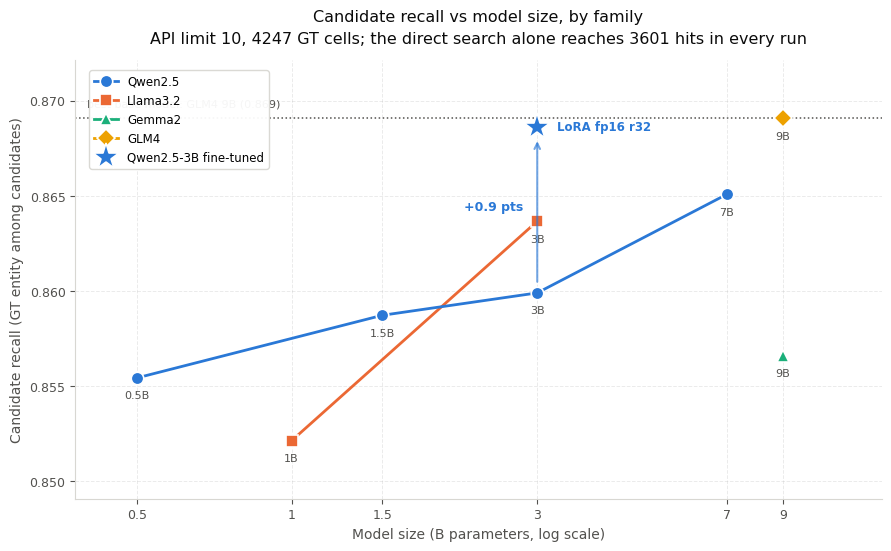

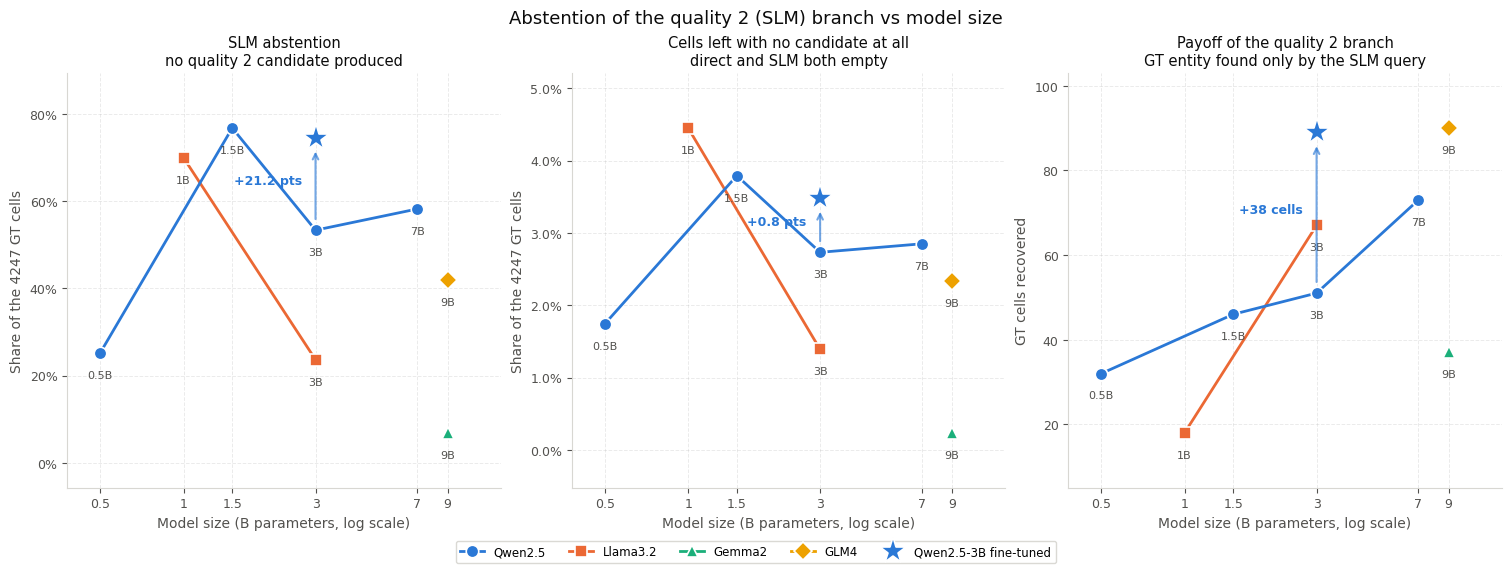

,family,size,label,tuned,recall,llm_abstention,cell_abstention,q2_hits
0,Qwen2.5,0.5,0.5B,False,0.855427,0.252178,0.017424,32
1,Qwen2.5,1.5,1.5B,False,0.858724,0.768072,0.037909,46
2,Qwen2.5,3.0,3B,False,0.859901,0.533553,0.027313,51
3,Qwen2.5,7.0,7B,False,0.865081,0.582293,0.028491,73
4,Llama3.2,1.0,1B,False,0.852131,0.699788,0.044502,18
5,Llama3.2,3.0,3B,False,0.863668,0.236402,0.013892,67
6,Gemma2,9.0,9B,False,0.856605,0.068519,0.002355,37
7,GLM4,9.0,9B,False,0.869084,0.418178,0.023311,90
8,Qwen2.5,3.0,3B LoRA fp16 r32,True,0.868613,0.745938,0.034848,89


In [ ]:
import matplotlib.pyplot as plt

N_GT = 4247

RUNS = [
    ("Qwen2.5",   0.5,  "0.5B",             False, 3633,   32,     1071,      74),
    ("Qwen2.5",   1.5,  "1.5B",             False, 3647,   46,     3262,      161),
    ("Qwen2.5",   3.0,  "3B",               False, 3652,   51,     2266,      116),
    ("Qwen2.5",   7.0,  "7B",               False, 3674,   73,     2473,      121),
    ("Llama3.2",  1.0,  "1B",               False, 3619,   18,     2972,      189),
    ("Llama3.2",  3.0,  "3B",               False, 3668,   67,     1004,      59),
    ("Gemma2",    9.0,  "9B",               False, 3638,   37,     291,       10),
    ("GLM4",      9.0,  "9B",               False, 3691,   90,     1776,      99),
    ("Qwen2.5", 3.0, "3B LoRA fp16 r32", True, 3689, 89, 3168, 148)
]

runs = pd.DataFrame(RUNS, columns=["family", "size", "label", "tuned", "gt_hits","q2_hits", "q2_no_cand", "no_cand_at_all"])
runs["recall"] = runs["gt_hits"] / N_GT
runs["llm_abstention"] = runs["q2_no_cand"] / N_GT
runs["cell_abstention"] = runs["no_cand_at_all"] / N_GT

FAMILY_COLOR = {"Qwen2.5": "#2a78d6", "Llama3.2": "#eb6834", "Gemma2": "#1baf7a", "GLM4": "#eda100"}
FAMILY_MARKER = {"Qwen2.5": "o", "Llama3.2": "s", "Gemma2": "^", "GLM4": "D"}
INK, INK_SOFT = "#0b0b0b", "#52514e"
XTICKS = [0.5, 1, 1.5, 3, 7, 9]


def _style_size_axis(ax, ylabel):
    ax.set_xscale("log")
    ax.set_xticks(XTICKS)
    ax.set_xticklabels([str(t) for t in XTICKS])
    ax.minorticks_off()
    ax.set_xlim(0.38, 14)
    ax.margins(y=0.18)
    ax.set_xlabel("Model size (B parameters, log scale)", color=INK_SOFT)
    ax.set_ylabel(ylabel, color=INK_SOFT)
    ax.tick_params(colors=INK_SOFT, labelsize=9)
    ax.grid(alpha=0.25, linestyle="--", linewidth=0.7)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    for s in ("left", "bottom"):
        ax.spines[s].set_color("#d8d7d2")


def _ordered_legend(target, ax, **kw):
    handles, labels = ax.get_legend_handles_labels()
    order = ["Qwen2.5", "Llama3.2", "Gemma2", "GLM4", "Qwen2.5-3B fine-tuned"]
    pairs = [(h, l) for name in order for h, l in zip(handles, labels) if l == name]
    return target.legend([h for h, _ in pairs], [l for _, l in pairs], frameon=True,framealpha=0.95, edgecolor="#d8d7d2", fontsize=8.5, **kw)


def _draw_families(ax, ycol, dy=-15):
    for family, g in runs[~runs["tuned"]].groupby("family"):
        g = g.sort_values("size")
        ax.plot(g["size"], g[ycol], linestyle="-", linewidth=2, color=FAMILY_COLOR[family],marker=FAMILY_MARKER[family], markersize=9, markeredgecolor="white",markeredgewidth=1.2, label=family, zorder=3)
        for _, r in g.iterrows():
            ax.annotate(r["label"], (r["size"], r[ycol]), textcoords="offset points",xytext=(0, dy), ha="center", fontsize=8, color=INK_SOFT)


def _draw_finetuned(ax, ycol, fmt="{:+.1f} pts", scale=100):
    ft = runs[runs["tuned"]].iloc[0]
    base = runs[(~runs["tuned"]) & (runs["family"] == "Qwen2.5") & (runs["size"] == 3.0)].iloc[0]
    c = FAMILY_COLOR["Qwen2.5"]
    ax.plot([ft["size"]], [ft[ycol]], marker="*", markersize=20, color=c, markeredgecolor="white",markeredgewidth=1.2, linestyle="none", label="Qwen2.5-3B fine-tuned", zorder=4)
    ax.annotate("", xy=(ft["size"], ft[ycol]), xytext=(base["size"], base[ycol]),arrowprops=dict(arrowstyle="->", color=c, linewidth=1.5, alpha=0.65,shrinkA=8, shrinkB=10))
    ax.annotate(fmt.format(scale * (ft[ycol] - base[ycol])),(ft["size"], (ft[ycol] + base[ycol]) / 2), textcoords="offset points",xytext=(-10, 0), ha="right", fontsize=9, color=c, fontweight="bold")
    return ft, base


def plot_recall_vs_size(out_png="Testing_data/fig_recall_vs_model_size.png"):
    fig, ax = plt.subplots(figsize=(8.8, 5.4), constrained_layout=True)
    _draw_families(ax, "recall")
    ft, base = _draw_finetuned(ax, "recall")
    ax.annotate("LoRA fp16 r32", (ft["size"], ft["recall"]), textcoords="offset points",xytext=(14, 0), ha="left", va="center", fontsize=8.5,color=FAMILY_COLOR["Qwen2.5"], fontweight="bold")

    base_only = runs[~runs["tuned"]]
    best = base_only.loc[base_only["recall"].idxmax()]
    ax.axhline(best["recall"], color=INK_SOFT, linestyle=":", linewidth=1.1, zorder=1)
    ax.text(0.015, best["recall"] + 0.0006,f"best base model: {best['family']} {best['label']} ({best['recall']:.3f})",fontsize=8, color=INK_SOFT, transform=ax.get_yaxis_transform(), ha="left")

    _style_size_axis(ax, "Candidate recall (GT entity among candidates)")
    ax.set_title("Candidate recall vs model size, by family\n"f"API limit 10, {N_GT} GT cells; the direct search alone reaches 3601 hits in every run",fontsize=11.5, color=INK, pad=12, linespacing=1.6)
    _ordered_legend(ax, ax, loc="upper left", bbox_to_anchor=(0.01, 0.99))
    fig.savefig(out_png, dpi=200, facecolor="white")
    print("Figure written to:", out_png)


def plot_abstention(out_png="Testing_data/fig_abstention_vs_model_size.png"):
    fig, axes = plt.subplots(1, 3, figsize=(15, 5.6), constrained_layout=True)

    _draw_families(axes[0], "llm_abstention", dy=-18)
    _draw_finetuned(axes[0], "llm_abstention")
    _style_size_axis(axes[0], "Share of the 4247 GT cells")
    axes[0].set_title("SLM abstention\nno quality 2 candidate produced", fontsize=10.5, color=INK)
    axes[0].yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")

    _draw_families(axes[1], "cell_abstention", dy=-18)
    _draw_finetuned(axes[1], "cell_abstention")
    _style_size_axis(axes[1], "Share of the 4247 GT cells")
    axes[1].set_title("Cells left with no candidate at all\ndirect and SLM both empty", fontsize=10.5, color=INK)
    axes[1].yaxis.set_major_formatter(lambda v, _: f"{v:.1%}")

    _draw_families(axes[2], "q2_hits", dy=-18)
    _draw_finetuned(axes[2], "q2_hits", fmt="{:+.0f} cells", scale=1)
    _style_size_axis(axes[2], "GT cells recovered")
    axes[2].set_title("Payoff of the quality 2 branch\nGT entity found only by the SLM query",fontsize=10.5, color=INK)

    _ordered_legend(fig, axes[0], loc="outside lower center", ncol=5)
    fig.suptitle("Abstention of the quality 2 (SLM) branch vs model size", fontsize=13, color=INK)
    fig.savefig(out_png, dpi=200, facecolor="white")
    print("Figure written to:", out_png)


plot_recall_vs_size()
plot_abstention()
plt.show()
runs[["family", "size", "label", "tuned", "recall", "llm_abstention", "cell_abstention", "q2_hits"]]


## Other dataset view 

In [ ]:
cea_gt = 'Testing_data/Candidate/Other_dataset/cea_gt.csv'

basic_other = 'Testing_data/Candidate/candidate_basic'
finetuned = 'Testing_data/Candidate/candidate_finetuned'

evaluate_candidate_cea_more_details(basic_other, cea_gt)
evaluate_candidate_cea_more_details(finetuned, cea_gt)

checking_retrieval(cea_gt, basic_other, cache_file, "Testing_data/Other_dataset/gt_analysis_basic.csv", sample_size=30)
checking_retrieval(cea_gt, finetuned, cache_file, "Testing_data/Other_dataset/gt_analysis_finetuned.csv", sample_size=30)

Evaluating candidates in Testing_data/Other_dataset/candidate_basic against GT in Testing_data/Other_dataset/cea_gt.csv
GT cells:22448
Cells with candidates retrieved:19652
GT entity present in candidates:17108
Recall Maximum possible:  0.762
The only candidate is not present:216
More than five candidates present but all incorrect:2090
GT entity present in candidates with quality 1: 16266
GT entity present in candidates with quality 2: 842
GT entity present in candidates with quality 3: 0
 Candidate rows per quality (all cells of the run) 
Candidate rows with quality 1 (direct): 64619
Candidate rows with quality 2 (llm): 102188
Candidate rows with quality 3 (fuzzy): 0
Cells with no candidate at all (quality 0 placeholder): 2796
Quality 1 (direct): no candidate for 5307 cells
Quality 2 (llm): no candidate for 13662 cells (LLM abstained or its suggested terms were not found on Wikidata)
Quality 3 (fuzzy): no candidate anywhere in this run (generator disabled or always empty)
Evaluating c

In [ ]:
def mcnemar_block(name, label, candidate_dir, runs, gt_file):
    print(f"=== {name} {label} ===")
    for run_name, candidate_dir in runs.items():
        print(f"--- {run_name} ---")
        checking_retrieval(gt_file, candidate_dir, cache_file, f"Testing_data/Other_dataset/gt_analysis_{name}_{label}_{run_name}.csv", sample_size=30)
        evaluate_candidate_cea_more_details(candidate_dir, gt_file)

folder_fuzzy = 'Testing_data/Candidate/Retrieval_fuzzy/candidate_fuzzy_direct_small'
other_folder_fuzzy = 'Testing_data/Candidate/Retrieval_fuzzy/candidate_fuzzy_direct'

cea_gt = 'Testing_data/cea_gt.csv'
other_cea_gt = 'Testing_data/Candidate/Other_dataset/cea_gt.csv'

evaluate_candidate_cea_more_details(folder_fuzzy, cea_gt)
evaluate_candidate_cea_more_details(other_folder_fuzzy, other_cea_gt)

mcnemar_block("FUZZY", "fuzzy_direct_small", folder_fuzzy, {"finetuned": finetuning_lora_32bit}, cea_gt)

mcnemar_block("FUZZY", "fuzzy_direct", other_folder_fuzzy, {"finetuned": finetuned }, other_cea_gt)

Evaluating candidates in Testing_data/Retrieval_fuzzy/candidate_fuzzy_direct_small against GT in Testing_data/cea_gt.csv
GT cells:4247
Cells with candidates retrieved:4136
GT entity present in candidates:3639
Recall Maximum possible:  0.857
The only candidate is not present:17
More than five candidates present but all incorrect:462
GT entity present in candidates with quality 1: 3602
GT entity present in candidates with quality 2: 0
GT entity present in candidates with quality 3: 37
 Candidate rows per quality (all cells of the run) 
Candidate rows with quality 1 (direct): 24592
Candidate rows with quality 2 (llm): 0
Candidate rows with quality 3 (fuzzy): 31153
Cells with no candidate at all (quality 0 placeholder): 111
Quality 1 (direct): no candidate for 246 cells
Quality 2 (llm): no candidate anywhere in this run (generator disabled or always empty)
Quality 3 (fuzzy): no candidate for 1653 cells
Evaluating candidates in Testing_data/Retrieval_fuzzy/candidate_fuzzy_direct against GT 

In [16]:
import itertools
import scipy.stats

def mcnemar_exact(hits_a, hits_b):
    b = c = 0
    for cell in hits_a:
        a_hit = hits_a[cell]
        b_hit = hits_b[cell]
        if a_hit and not b_hit:
            b += 1
        elif not a_hit and b_hit:
            c += 1
    n = b + c
    p = 1.0 if n == 0 else 2 * min(scipy.stats.binom.cdf(b, n, 0.5), scipy.stats.binom.sf(b - 1, n, 0.5))
    return b, c, p
def per_cell_hits_quality(candidate_dir, ground_truth_file, qualities=None):
    PREFIX = "http://www.wikidata.org/entity/"

    frames = []
    for path in sorted(glob.glob(os.path.join(candidate_dir, "*_candidates.csv"))):
        df = pd.read_csv(path, dtype=str, keep_default_na=False,usecols=["row", "columns", "QID", "quality"])
        df["tab_id"] = os.path.basename(path).replace("_candidates.csv", "")
        frames.append(df)

    pairs = set()
    if frames:
        cand = pd.concat(frames, ignore_index=True)
        if qualities is not None:
            cand = cand[cand["quality"].isin(set(qualities))]
        cell = cand["tab_id"] + " " + (cand["row"].astype(int) + 1).astype(str) + " " + cand["columns"]
        pairs = set(zip(cell, cand["QID"]))

    gt = pd.read_csv(ground_truth_file, names=["tab_id", "row_id", "col_id", "entity"],dtype=str, keep_default_na=False)
    hits = {}
    for r in gt.itertuples(index=False):
        cell = f"{r.tab_id} {r.row_id} {r.col_id}"
        hits[cell] = (cell, r.entity.replace(PREFIX, "")) in pairs
    return hits


def mcnemar_pairwise_table(runs, ground_truth_file, qualities=None, holm=False, verbose=True):
    hits = {name: per_cell_hits_quality(d, ground_truth_file, qualities) for name, d in runs.items()}
    if verbose:
        channel = "All qualities" if qualities is None else "quality " + "+".join(sorted(qualities))
        n_gt = len(next(iter(hits.values())))
        print(f"recall on {n_gt} GT cells ({channel}) :")
        for name, h in hits.items():
            k = sum(h.values())
            print(f"  {name:18s} {k:6d}  ({k / n_gt:.4f})")
        print()
    rows = []
    for name_a, name_b in itertools.combinations(runs, 2):
        b, c, p = mcnemar_exact(hits[name_a], hits[name_b])
        rows.append({"compared_1": name_a, "compared_2": name_b, "b": b, "c": c, "p_value": p})
    table = pd.DataFrame(rows, columns=["compared_1", "compared_2", "b", "c", "p_value"])
    if holm:
        table = table.sort_values("p_value", kind="stable").reset_index(drop=True)
        m = len(table)
        table["p_holm"] = (table["p_value"] * (m - table.index)).clip(upper=1.0).cummax()
        table["favors"] = [r.compared_1 if r.b > r.c else (r.compared_2 if r.c > r.b else "-")  for r in table.itertuples()]
    return table

runs_fuzzy_vs_slm = {
    "fuzzy_direct": folder_fuzzy,
    "qwen25_0_5b":  qwen25_0_5b_dir,
    "llama32_3b":   llama32_3b_dir,
    "glm4_9b":      glm_9b_dir,
    "qwen3b_ft":    finetuning_lora_32bit,
}

print("BLOC 1: direct+fuzzy vs SLM (CEA dataset)")
table_fuzzy_vs_slm = mcnemar_pairwise_table(runs_fuzzy_vs_slm, cea_gt, holm=True)
display(table_fuzzy_vs_slm)


runs_fuzzy_vs_slm_other = {
    "fuzzy_direct":  other_folder_fuzzy,
    "slm_basic":     basic_other,
    "slm_finetuned": finetuned,
}

print(" BLOC 2 : direct+fuzzy vs SLM (Other dataset)")
table_fuzzy_vs_slm_other = mcnemar_pairwise_table(runs_fuzzy_vs_slm_other, other_cea_gt, holm=True)
display(table_fuzzy_vs_slm_other)


BLOC 1: direct+fuzzy vs SLM (CEA dataset)
recall on 4247 GT cells (All qualities) :
  fuzzy_direct         3639  (0.8568)
  qwen25_0_5b          3633  (0.8554)
  llama32_3b           3668  (0.8637)
  glm4_9b              3691  (0.8691)
  qwen3b_ft            3689  (0.8686)



,compared_1,compared_2,b,c,p_value,p_holm,favors
0,qwen25_0_5b,glm4_9b,10,68,9.708115e-12,9.708115e-11,glm4_9b
1,qwen25_0_5b,qwen3b_ft,13,69,2.255847e-10,2.030263e-09,qwen3b_ft
2,fuzzy_direct,glm4_9b,11,63,5.321301e-10,4.257041e-09,glm4_9b
3,fuzzy_direct,qwen3b_ft,22,72,2.260598e-07,1.582419e-06,qwen3b_ft
4,qwen25_0_5b,llama32_3b,11,46,3.311885e-06,1.987131e-05,llama32_3b
5,fuzzy_direct,llama32_3b,13,42,1.136106e-04,5.680530e-04,llama32_3b
6,llama32_3b,glm4_9b,18,41,3.793706e-03,1.517482e-02,glm4_9b
7,llama32_3b,qwen3b_ft,33,54,3.141811e-02,9.425433e-02,qwen3b_ft
8,fuzzy_direct,qwen25_0_5b,25,19,4.513808e-01,9.027617e-01,fuzzy_direct
9,glm4_9b,qwen3b_ft,36,34,9.049745e-01,9.049745e-01,glm4_9b


 BLOC 2 : direct+fuzzy vs SLM (Other dataset)
recall on 22448 GT cells (All qualities) :
  fuzzy_direct        17287  (0.7701)
  slm_basic           17108  (0.7621)
  slm_finetuned       17923  (0.7984)



,compared_1,compared_2,b,c,p_value,p_holm,favors
0,slm_basic,slm_finetuned,306,1121,2.534960e-109,7.604881e-109,slm_finetuned
1,fuzzy_direct,slm_finetuned,602,1238,1.414046e-50,2.828091e-50,slm_finetuned
2,fuzzy_direct,slm_basic,697,518,3.129899e-07,3.129899e-07,fuzzy_direct


In [ ]:
runs_best = {
    "glm9b_L10":     glm_9b_dir,
    "glm9b_L30":     glm_9b_dir_30,
    "glm9b_L50":     glm_9b_dir_50,
    "qwen3b_ft_L10": finetuning_lora_32bit,
    "qwen3b_ft_L30": finetuning_lora_32bit_30,
    "qwen3b_ft_L50": finetuning_lora_32bit_50,
}

print("Best configs, all qualities")
table_best = mcnemar_pairwise_table(runs_best, ground_truth_file, holm=True)
display(table_best)

print("Best configs, quality 1+3")
table_best_q13 = mcnemar_pairwise_table(runs_best, ground_truth_file, qualities=("1", "3"), holm=True)
display(table_best_q13)


Best configs, all qualities
recall on 4247 GT cells (All qualities) :
  glm9b_L10            3691  (0.8691)
  glm9b_L30            3846  (0.9056)
  glm9b_L50            3882  (0.9141)
  qwen3b_ft_L10        3689  (0.8686)
  qwen3b_ft_L30        3839  (0.9039)
  qwen3b_ft_L50        3871  (0.9115)



,compared_1,compared_2,b,c,p_value,p_holm,favors
0,glm9b_L10,glm9b_L50,0,191,6.372368e-58,9.558551e-57,glm9b_L50
1,qwen3b_ft_L10,qwen3b_ft_L50,0,182,3.262652e-55,4.567713e-54,qwen3b_ft_L50
2,glm9b_L10,glm9b_L30,0,155,4.379058e-47,5.692775e-46,glm9b_L30
3,qwen3b_ft_L10,qwen3b_ft_L30,0,150,1.401298e-45,1.681558e-44,qwen3b_ft_L30
4,glm9b_L50,qwen3b_ft_L10,220,27,8.476403e-39,9.324043e-38,glm9b_L50
5,glm9b_L10,qwen3b_ft_L50,32,212,9.392020e-34,9.392020e-33,qwen3b_ft_L50
6,glm9b_L30,qwen3b_ft_L10,184,27,6.540066e-30,5.886060e-29,glm9b_L30
7,glm9b_L10,qwen3b_ft_L30,32,180,3.299925e-26,2.639940e-25,qwen3b_ft_L30
8,glm9b_L30,glm9b_L50,0,36,2.910383e-11,2.037268e-10,glm9b_L50
9,qwen3b_ft_L30,qwen3b_ft_L50,0,32,4.656613e-10,2.793968e-09,qwen3b_ft_L50


Best configs, quality 1+3
recall on 4247 GT cells (quality 1+3) :
  glm9b_L10            3601  (0.8479)
  glm9b_L30            3752  (0.8834)
  glm9b_L50            3788  (0.8919)
  qwen3b_ft_L10        3600  (0.8477)
  qwen3b_ft_L30        3752  (0.8834)
  qwen3b_ft_L50        3787  (0.8917)



,compared_1,compared_2,b,c,p_value,p_holm,favors
0,glm9b_L50,qwen3b_ft_L10,188,0,5.097894e-57,7.646841e-56,glm9b_L50
1,glm9b_L10,glm9b_L50,0,187,1.019579e-56,1.427410e-55,glm9b_L50
2,qwen3b_ft_L10,qwen3b_ft_L50,0,187,1.019579e-56,1.427410e-55,qwen3b_ft_L50
3,glm9b_L10,qwen3b_ft_L50,0,186,2.039158e-56,2.446989e-55,qwen3b_ft_L50
4,glm9b_L30,qwen3b_ft_L10,152,0,3.503246e-46,3.853571e-45,glm9b_L30
5,qwen3b_ft_L10,qwen3b_ft_L30,0,152,3.503246e-46,3.853571e-45,qwen3b_ft_L30
6,glm9b_L10,glm9b_L30,0,151,7.006492e-46,6.305843e-45,glm9b_L30
7,glm9b_L10,qwen3b_ft_L30,0,151,7.006492e-46,6.305843e-45,qwen3b_ft_L30
8,glm9b_L30,glm9b_L50,0,36,2.910383e-11,2.037268e-10,glm9b_L50
9,glm9b_L50,qwen3b_ft_L30,36,0,2.910383e-11,2.037268e-10,glm9b_L50
